# Convolutional Layers
Before we being, I made this notebook and took notes from https://towardsdatascience.com/the-math-behind-convolutional-neural-networks-6aed775df076/#37ff 
Now, 
# The Convolution Operation

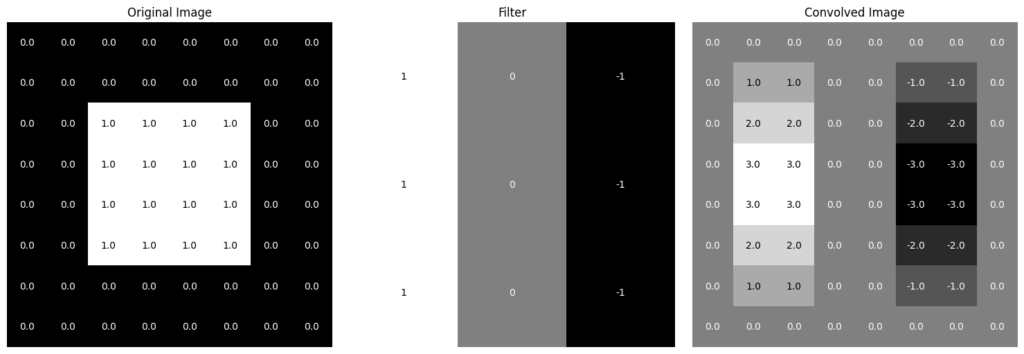


The convolution operation involves a sliding a filter (or kernel) over the input image and computing the dot product of filter values and the original pixel values at each position. Typically, we create a small matrix of weights, typically of size 3x3 or 5x5. Lets go over why we'd use these two sizes.

For example, a signle 7x7 filter has 49 paramters. Three stacked 3x3 filters covers a 7x7 **receptive** field - but only uses 27 paramters total (3x9). We typically want less paramters total for a lower risk of overfitting. 

Secondly, if we stack many small filters we introduce more nonlinearity as these filters must go through their respective activation functions (ReLU) - meaning the network learns *more complex* transformations than one big linear filter.


| Advantage | Explanation | 
|----------------------|-----------| 
| Fewer Parameters → Lower Overfitting Risk | A single 7×7 filter has 49 weights, while stacking three 3×3 filters reaches the same receptive field (7×7) using only 27 weights. Fewer parameters make the model more efficient and less prone to overfitting.  |
| More Nonlinearity → More Expressive Power | Each small filter is followed by an activation like ReLU, so three stacked 3×3 filters apply ReLU three times. A single 7×7 filter only gets one ReLU. More nonlinear layers = richer feature transformations. |
| Builds Features Hierarchically (Like Human Perception) | Small filters force the network to learn simple patterns first (edges), then combine them into textures, and later into shapes or objects. Large filters try to learn everything at once and lose this structured abstraction. |




Mathmatically, the convolution operation can be expressed as: 
$$
S(i,j) = (I * K)(i,j) = \sum_m \sum_n I(i+m, j+n) \cdot K(m,n)
$$
* Where S(i, j) is the output feature map.
* I is the input image.
* K is the kernel or filter
* i, j are the coordinates on the feature map
* m, n are the coordinates in the kernel. 
* (*) denotes the convolution operation. 

In english, this equation tells us that each element S(i, j) of the output feature map is the sum of element wise product of the kernel K and the portion of the input image I over which the kernel is currently positioned. 
In other words we think of I our grid of pixel values, while K is the small filter like a 3x3 grid with numbers in it. Finally, we'd have S as our output image. 
At every position (i, j) in the output S:
1. Place the kernel K on top of the input image I, aligning its top-left corner position to (i, j). 
2. Multiply each value of the kernel with the pixel directly underneat it. 
    * e.g., $K (0, 0) \times I(i, j)$
    * $K(0, 1) \times I(i, j + 1)$
    * $K(1, 0) \times I(i + 1, j)$, etc. 
3. Add up all those products, our total becomes S(i, j)

Typically, the values inside the kernel are the weights learned during training, but   
Suppose the kernel is $ K = 
\begin{bmatrix}
 1 & 0 & -1 \\
 1 & 0 & -1 \\
 1 & 0 & -1 
 \end{bmatrix}
 $ And you slide over region I, I region under kernel 
 $ =
\begin{bmatrix}
10 & 20 & 30 \\
15 & 25 & 35 \\
20 & 30 & 40 
\end{bmatrix}
 $
 Then, 
 $$
 S(i, j) = 
(1 \cdot 10) + (0 \cdot 20) + (-1 \cdot 30) \\
+ (1 \cdot 15) + (0 \cdot 25) + (-1 \cdot 35) \\
+ (1 \cdot 20) + (0 \cdot 30) + (-1 \cdot 40) \\
 S(i, j) = -60
 $$

We'd end up multiplying each kernel cell by its corresponding image pixel, then sum all of them. 
Once the full S is built, that feature map represents how strongly the kernel **matched** different parts of the image. 
| Type of Kernel | Meaning of High Output Values in S | 
-------------------|----------------------------------
| Edge detector | Bright areas in S = strong vertical edges in input |
| Blur kernel | smooths the image |
| Sharpen kernel | Amplifies contours |
| CNN Learned kernel | Detects whatever pattern it evolved to detect |




# Stride


![My GIF](JupyterNotebookVisuals\1OlE3bnC0WaYt3wW1dlcMdA.gif)


A stride specifies the number of pixels we'll move a filter across the input image or feature map in each step. The stride is applied both horizontally and vertically. If we had a stride of 1, then we'd move one pixel at a time (our anchor point). When we have larger strides, the filter will skip pixels and leading to less dense convergance. Typically, we denote the top left part of the filter as our **anchor** and reference the movement of the top left coordinate onto the rest of the cells. 
* **With a Stride of 1**: The filter moves across every pixel, with a resulting output feature map that is relatively large or similar in size to the input.
* **With a Stride greater than 1**: Our filter will skip over pixels which means we cover the input in few steps. The result is a smaller output feature map as each step covers a larger area of the inptu with less overlap between positions where the feature is applied. 
Suppose input is 
  $ I = 
\begin{bmatrix}
 A & B & C & D & E \\
 F & G & H & I & J \\
 K & L & M & N & O \\
 P & Q & R & S & T \\
 U & V & W & X & Y 
 \end{bmatrix}
$ 
    
Our 3x3 filter first covers 
If stride = 1, then $
\begin{bmatrix}
 B & C & D \\
 G & H & I \\
 L & M & N 
 \end{bmatrix}
$
If stride = 2, then $
\begin{bmatrix}
 C & D & E \\
 H & I & J \\
 M & N & O 
 \end{bmatrix}
$
* When our stride is larger, we have less overlap, and we'll end up with a smaller output. 

**Mathmatical Representation**: We can calculate the size of the ouptut feature map (_Wout, _Hout) from the input size (_Win, _Hin), filter size (F), stride (S), and padding (P) using the formula. 

$$
W_{out} = \frac{W_{in} - F + 2P}{S} + 1
$$
$$
H_{out} = \frac{H_{in} - F + 2P}{S} + 1
$$
where:
* _Wout and _Hout are the width and height of the ouptut feature map respectively. 
* _Win and _Hin are the width and height of the input respectively. 
* F is the size of the filter.
* S is the stride. 
* P is the padding. 

Ex:
Input = 5x5, Image 
Filer = 3x3,
Stride = 1,
Padding = 0
$$
W_{out} = \frac{5 - 3 + 2(0)}{1} + 1 = 3
$$
$$
H_{out} = \frac{5 - 3 + 2(0)}{1} + 1 = 3
$$
With the example shown, our output becomes 3x3 where we **lost** the border information. To visualize the problem we need to solve, pay attention to the top left pixel and notice how we only capture the information in the pixel once.

<img src="JupyterNotebookVisuals\6x6matrix-1.png" width="300">
<img src="JupyterNotebookVisuals\6x6matrix-2.png" width="300">
<img src="JupyterNotebookVisuals\6x6matrix-3.png" width="300">
  
<img src="JupyterNotebookVisuals\6x6matrix-4.png" width="300">

The pixels that are towards the middle may be captured up to nine times compared to our edge pixel at position (0,0)! 

When our edge pixels are only hit by the filter once then 
* Edge features become underrepresented compared to central features.
* The model becomes biased towards the center of the image, so our model learns more from the central pixels rather than in an more equal setting
* Edge patterns like borders, corners, and partial objects at the edge may get ignored. 

# Padding

![My GIF](JupyterNotebookVisuals/1VwOf7sD87Yw9P1215NngRQ.gif)


In the example above, the orginal image which was a 8x8 matrix has been increased to a 10x10 matrix with a padding of one. We have now added:
* 1 extra row on top
* 1 extra row on bottom
* 1 extra row on left
* 1 extra row on right

Without padding, every time we perform the convolution operation we'd lose spatial information about the original image. With padding, we can apply filters without shrinking the spatial dimensions. Additionally, the filters are then able to process the edge pixels of the image. Thus, the edge pixels (such as all pixels in the first row or column, and all pixels in the last row or column) are captured and used in the networks learning process. 

Typically with the layers that are created, we most commonly set their values to zero. There are cases to avoid using zero padding:

| Scenario | Why | Alternative Padding | 
-------------------|----------------------|------------
| Edge-sensitive data (medical images) | Zero-padding introduces artificial low-intensity borders, which aren't physically meaningful. | Reflective or replicate padding ("mirror" or "edge) |
| Training with small inputs | Zeros may dominate the real data given the convolution depth | Incorporate learned padding value or no padding with cropping|

<img src="JupyterNotebookVisuals\outputmatrix.png" width="800">

We'll now adjust the previous formula to account for padding. 
$$
W_{out} = \frac{W_{in} + 2P-F}{S} + 1
$$
$$
H_{out} = \frac{H_{in} + 2P-F}{S} + 1
$$
where:
* _Wout and _Hout are the width and height of the ouptut feature map respectively. 
* _Win and _Hin are the width and height of the input respectively. 
* F is the size of the filter.
* S is the stride. 
* P is the padding. 

With this formula, we now know that padding presevers spatial dimensions when:
$$
P = \frac{F-1}{2} \quad\quad \text{(For odd sized filters, stride 1)}
$$

Ex:
Input = 6x6, Image 
Filer = 3x3,
Stride = 1,
Padding = 1
$$
W_{out} = \frac{6 + 2(1) - 3}{1} + 1 = 6
$$
$$
H_{out} = \frac{6 + 2(1) - 3}{1} + 1 = 6
$$
Padding is essential for preserving spatial dimensions and fairly exposing edge pixels to convolution, but overpadding increases computation while introducing artificial borders. This creates a weaker learning signal at the periphery and can harm generalization if the model starts learning from zeros rather than real data.


# Weight Sharing

If each location in the image had its own unique filter (instead of reusing the same filter), the total number of parameters would scale with both the filter size and the number of spatial positions. In other words,
*  each position in a given image would need it's own unique filter of size nxm. 
* For a 28x28 image, there are 784 combinations of positions (assuming 1 stride and 0 padding)
* That would give $ 28 \cdot 28 \cdot 3 \cdot 3 = 7056 \text{    paramters}$

When we incorporate weight sharing, the network is able to detect features regardless of their position in the input image. Meaning, if we learn of a specific pattern or an edge, we can detect said feature anywhere in the image. 
Therefore, CNNs are translation invariant. 

In weight sharing, we pass the filter with a fixed set of wegihts and slide it over the input image. Of course, we perform the convolution operation (a matrix product) between the filter and the region of the input image we are sliding it over. When performing the convolution operation, we begin making a feature map that indicates the presennce and intensity fo teh detected feature across the spacial extent of an image. 
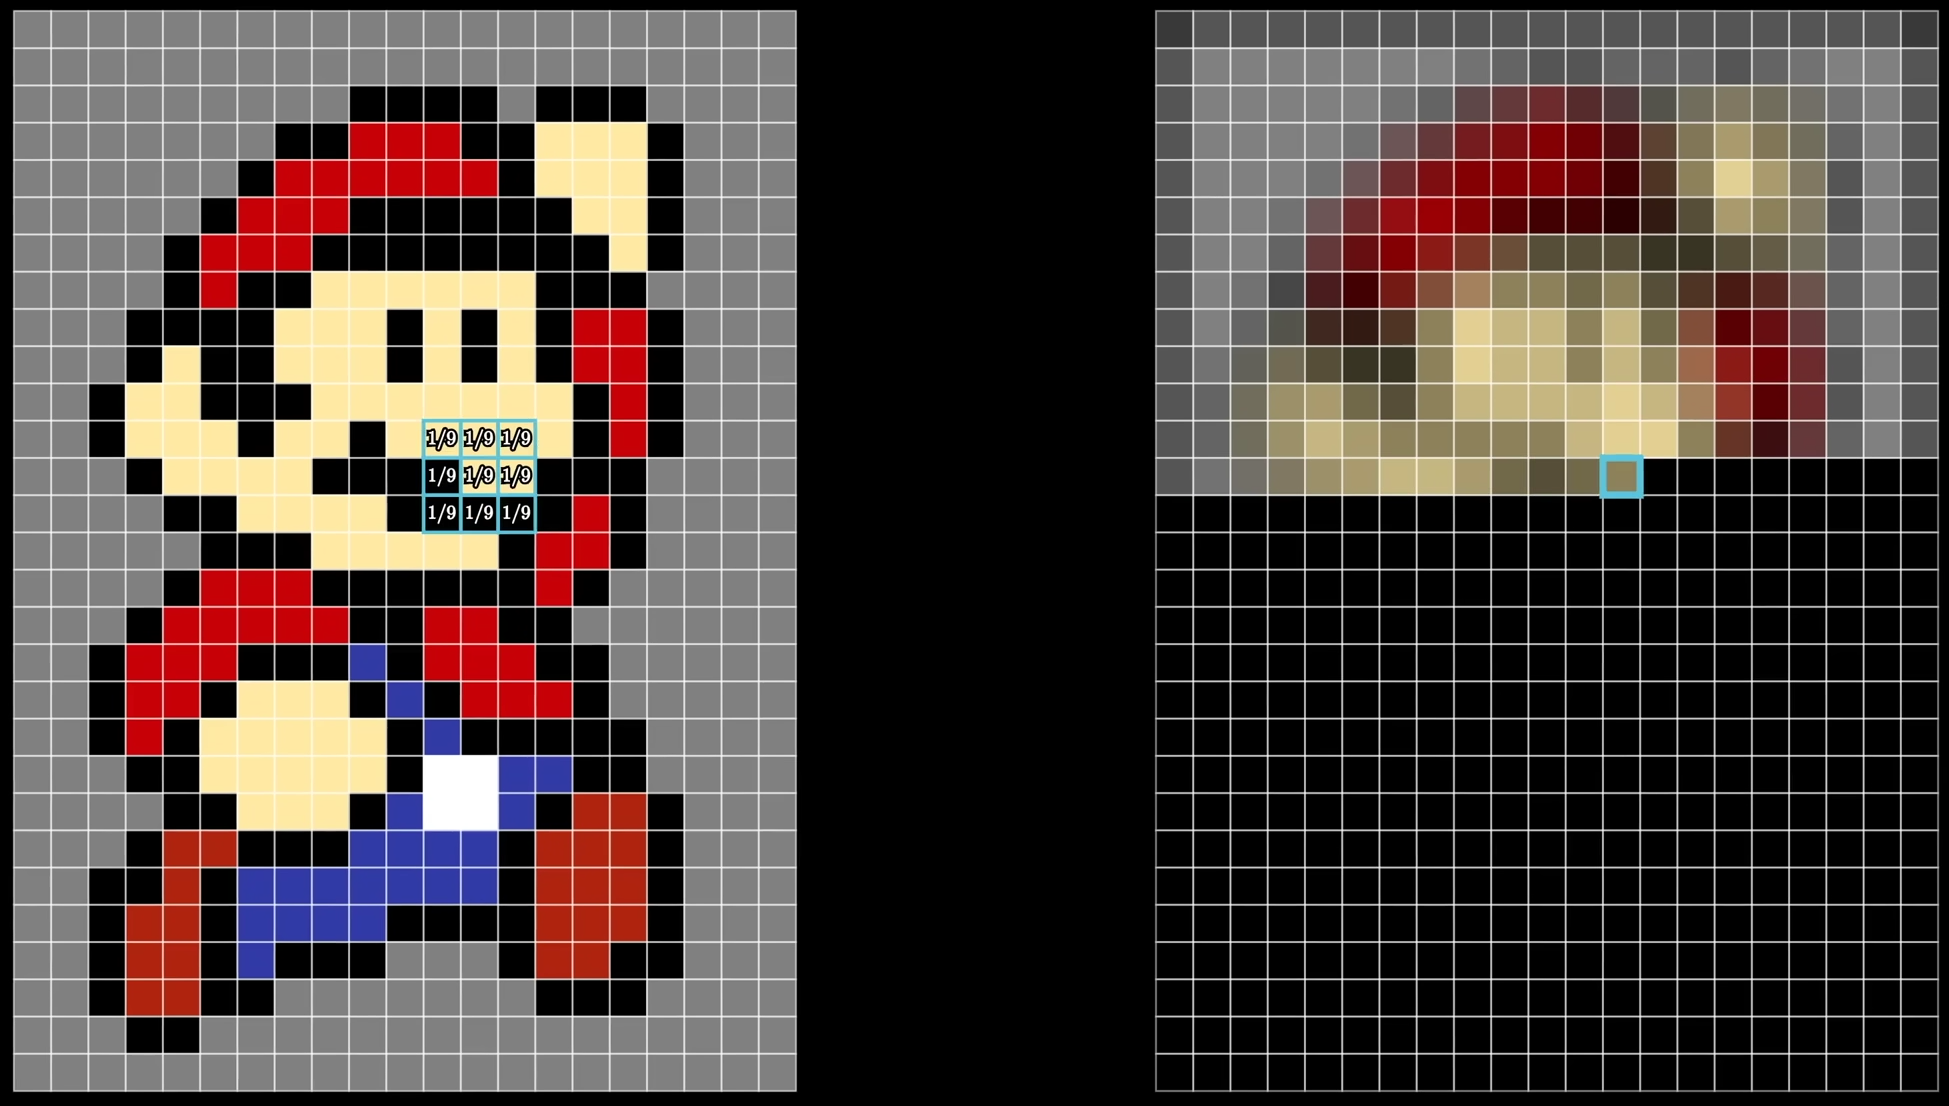
* Input Image on the left, with a 3x3 filter being slid across it. Output feature map on the right, where each pixel being a scaler result of the convolution operation for each region.

In the above example, when take a 3x3 filter (in this case with all nine weights being 1/9), we get an image that is a blur of the original. The blur occurs from us taking an average of all nine pixel values in the I(i +m, j + n) region of the input image. 
Our result here is a **low-frequency** representation of the image: a blurred version where the main shapes are visible, but our edge details are lost.

# Pooling Layers: 
In a typical **convolutional block**, the order of steps is: 
$$
{\Large\text{Input} \xrightarrow{\text{Convolution}} \,\ \xrightarrow{\text{Activation Function}} \,\ \xrightarrow{\text{Pooling}} }
$$

Pooling Layers aim to reduce the spatial dimensions of the feature maps. In ML, we aim to reduce computational load by balancing the number of paramters we want to use for a given model. Pooling layers summarize the presence of features in patches of the feature map, pooling. We'll go over a few common pooling techniques. 
First, with a feature map with $n_h \times n_w \times n_c $, the dimensions of the output after a pooling layer will be:
$$
\left( \frac{n_h - f + 1}{s} \right) \times \left( \frac{n_w - f + 1}{s} \right) \times n_c
$$
Where:  
* $n_h \rightarrow $ height of the feature map  
* $n_w \rightarrow $ width of the feature map  
* $n_c \rightarrow $ number of channels in the feature map  
* $f \rightarrow $ size of the pooling filter  
* $s \rightarrow $ stride length  

**Max Pooling** is the most common form of pooling, where for each local window in the feature map, we return the maximum value within that window. This operation captures the most pronounced or dominant features, helping the network focus on the strongest activations while reducing spatial size.
$$
P_{\text{max}}(i, j) = \max_{0 \le a < n, \, 0 \le b < n} F(i \cdot s + a, \, j \cdot s + b)
$$
Where:
* $P_{max} (i, j)\text{: the pooled value at position } (i,j)$
* $F$: the input feature map
* $n$: the pooling windows size (e.g, 2x2, 3x3, etc)
* $s$: the stride
* $a, b$: iterate over the window dimensions

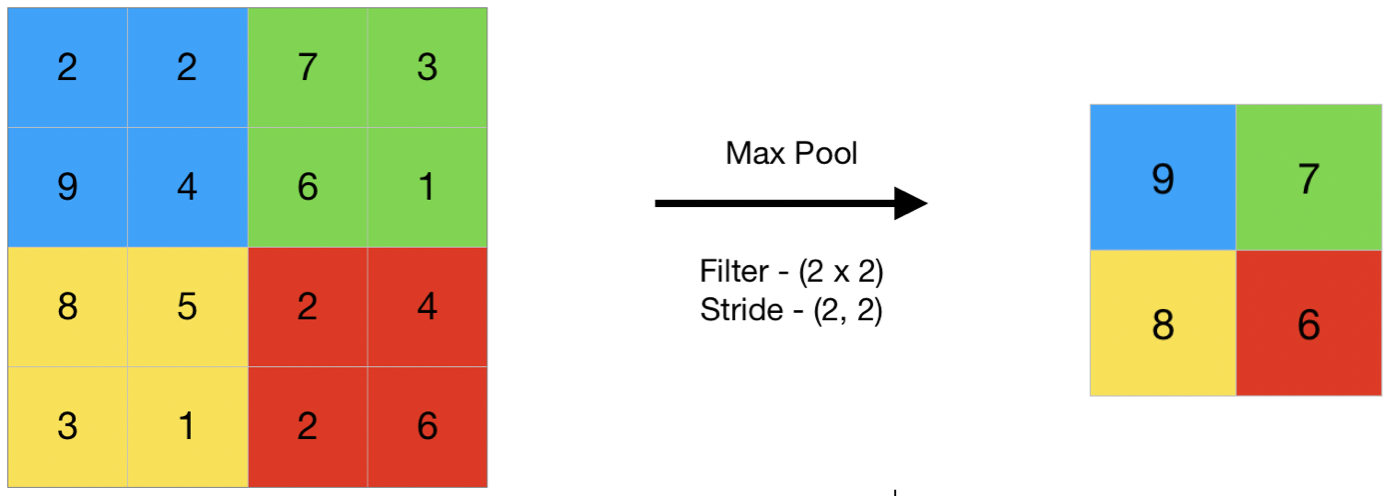

**Average Pooling** works similarly by taking an average of the values within each local window of the feature map. This method will return a more generalized feature representation but overshadow smaller, yet significant features. These fine-grained features tend to get *washed out* by surrounding low activations.  

$$
P_{\text{avg}}(i, j) = \frac{1}{n^2} \sum_{a=0}^{n-1} \sum_{b=0}^{n-1} F(i \cdot s + a, \; j \cdot s + b)
$$
Where:
* $F \rightarrow$ input feature map
* $P_{avg} (i,j) \rightarrow \text{pooled output at position } \, (i,j) $
* $n \times n \rightarrow $ pooling window size
* $s \rightarrow $ stride
* $\text{The} \,\frac{1}{n^2}$ term ensures we're taking the **average** and not just the sum of all the values within the window. 

It'll look identical in structure to max pooling, except instead of taking 
$$
\underset{\text{window}}{\max} F(i, j)\quad \text{we take} \quad \frac{1}{n^2} \sum_{a, b}
$$
Ex: 
Imagine a $ 2 \times 2 $ window with feature activations. 
$ 
\begin{bmatrix}
0.1 & 0.2 \\
0.1 & 0.9
 \end{bmatrix}
$
* **Max Pooling: max** = 0.9 $\rightarrow$ retains the strong activation on the edge. 
* **Average Pooling:** $\frac {0.1 + 0.2 + 0.1 + 0.9}{4} = 0.325 \,\rightarrow $ greatly reduces that signal

In essence, max pooling preserves the presence of a distincitve feature, while average pooling dilutes it. When we have sharp or localized feature like edges, corners, or small patterns, we'd perfer max pooling over average pooling. 